SETUP

In [5]:
import os
import re
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = r"C:\Users\user\Desktop\Final Project"
os.chdir(PROJECT_DIR)
os.makedirs("output/charts", exist_ok=True)
os.makedirs("output/results", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

KEBS = {
    "ph_min": 6.5, "ph_max": 8.5,
    "conductivity": 2500,
    "tds": 1000,
    "alkalinity": 500,
    "colour": 15,
}

print("✅ Setup complete")

✅ Setup complete


Load Data and Detect Columns

In [6]:
conn = sqlite3.connect("data/processed/kenya_water.db")
kewi = pd.read_sql_query("SELECT * FROM kewi_water_tests", conn)
conn.close()
print(f"Loaded {len(kewi)} samples")

def norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def find_col(df, candidates):
    cols_norm = {c: norm(c) for c in df.columns}
    for cand in candidates:
        cn = norm(cand)
        for c, ccn in cols_norm.items():
            if cn == ccn or cn in ccn or ccn in cn:
                return c
    return None

COL_COUNTY = find_col(kewi, ["COUNTY"])
COL_SOURCE = find_col(kewi, ["TYPE_OF_H2O", "TYPE_OF_WATER"])
COL_DATE   = find_col(kewi, ["DATE"])
COL_PH     = find_col(kewi, ["PH"])
COL_COND   = find_col(kewi, ["CONDUCTIVITY"])
COL_TDS    = find_col(kewi, ["TOTAL_DISSOLVED", "TDS"])
COL_ALK    = find_col(kewi, ["ALKALINITY"])
COL_COLOUR = find_col(kewi, ["COLOUR"])

print(f"Detected: pH={COL_PH}, cond={COL_COND}, tds={COL_TDS}, alk={COL_ALK}, colour={COL_COLOUR}")
print(f"county={COL_COUNTY}, source={COL_SOURCE}, date={COL_DATE}")

Loaded 493 samples
Detected: pH=PH, cond=CONDUCTIVITY?S/cm, tds=Total_Dissolved_Solids, alk=ALKALINITY_Mg/L, colour=COLOUR
county=COUNTY, source=TYPE_OF_H2O, date=DATE


Convert to Numeric + Coverage Report

In [7]:
for col in [COL_PH, COL_COND, COL_TDS, COL_ALK, COL_COLOUR]:
    if col:
        kewi[col + "_num"] = pd.to_numeric(kewi[col], errors="coerce")

PH   = COL_PH + "_num"     if COL_PH else None
COND = COL_COND + "_num"   if COL_COND else None
TDS  = COL_TDS + "_num"    if COL_TDS else None
ALK  = COL_ALK + "_num"    if COL_ALK else None
COL  = COL_COLOUR + "_num" if COL_COLOUR else None

kewi[COL_COUNTY] = kewi[COL_COUNTY].astype(str).str.strip()
kewi[COL_SOURCE] = kewi[COL_SOURCE].astype(str).str.strip()
kewi["date_parsed"] = pd.to_datetime(kewi[COL_DATE], errors="coerce")
kewi["month"] = kewi["date_parsed"].dt.to_period("M").astype(str)

print("=== Parameter coverage (of 493 samples) ===")
for name, col in [("pH", PH), ("Conductivity", COND), ("TDS", TDS),
                  ("Alkalinity", ALK), ("Colour", COL)]:
    if col:
        n = kewi[col].notna().sum()
        print(f"  {name:15s} {n:4d}  ({n/len(kewi)*100:.1f}%)")

print(f"\n=== Date range ===")
print(f"  Earliest: {kewi['date_parsed'].min()}")
print(f"  Latest:   {kewi['date_parsed'].max()}")
print(f"  Unique months: {kewi['month'].nunique()}")

=== Parameter coverage (of 493 samples) ===
  pH               433  (87.8%)
  Conductivity     410  (83.2%)
  TDS              417  (84.6%)
  Alkalinity       389  (78.9%)
  Colour           406  (82.4%)

=== Date range ===
  Earliest: 2011-12-20 00:00:00
  Latest:   2016-07-08 00:00:00
  Unique months: 40


Clean County Names (Map to Kenya's 47 Counties)

In [9]:
# ============================================================
# CELL 4 — Clean county names, keep all 47 Kenyan counties
# ============================================================

# All 47 official Kenyan counties
KENYA_COUNTIES = [
    "Baringo", "Bomet", "Bungoma", "Busia", "Elgeyo-Marakwet", "Embu",
    "Garissa", "Homa Bay", "Isiolo", "Kajiado", "Kakamega", "Kericho",
    "Kiambu", "Kilifi", "Kirinyaga", "Kisii", "Kisumu", "Kitui",
    "Kwale", "Laikipia", "Lamu", "Machakos", "Makueni", "Mandera",
    "Marsabit", "Meru", "Migori", "Mombasa", "Murang'a", "Nairobi",
    "Nakuru", "Nandi", "Narok", "Nyamira", "Nyandarua", "Nyeri",
    "Samburu", "Siaya", "Taita-Taveta", "Tana River", "Tharaka-Nithi",
    "Trans Nzoia", "Turkana", "Uasin Gishu", "Vihiga", "Wajir", "West Pokot"
]

# Build a lookup: normalized name -> official county
def normalize(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

KENYA_LOOKUP = {normalize(c): c for c in KENYA_COUNTIES}

# Variants that map to an official county
VARIANT_MAP = {
    "homabay": "Homa Bay",
    "sondu": "Kisumu",
    "nyando": "Kisumu",
    "kisumueast": "Kisumu",
    "lodwar": "Turkana",
    "lokichoggio": "Turkana",
    "mwingi": "Kitui",
    "thika": "Kiambu",
    "taitataveta": "Taita-Taveta",
    "tharakantihi": "Tharaka-Nithi",
    "elgeyomarakwet": "Elgeyo-Marakwet",
    "muranga": "Murang'a",
}

# Known NON-Kenyan locations and old provinces → drop
NON_KENYAN = {
    "somalia", "mogadishu", "mogadishusomalia",
    "moshitanzania", "iringatanzania", "iringa",
    "northernbaherelghazalsouthernsudan",
    "central", "riftvalley",
}

def map_county(raw):
    """Map a raw county value to an official Kenyan county, or None to drop."""
    if pd.isna(raw):
        return None
    key = normalize(raw)

    # 1. Direct match to official county
    if key in KENYA_LOOKUP:
        return KENYA_LOOKUP[key]

    # 2. Variant mapping
    if key in VARIANT_MAP:
        return VARIANT_MAP[key]

    # 3. Explicit drop list (non-Kenyan, old provinces)
    if key in NON_KENYAN:
        return None

    # 4. Unknown — keep as-is but flag it
    return f"UNKNOWN: {raw}"

# Apply mapping
kewi["county_clean"] = kewi[COL_COUNTY].apply(map_county)

# Report
dropped = kewi[kewi["county_clean"].isna()]
unknown = kewi[kewi["county_clean"].astype(str).str.startswith("UNKNOWN")]

print(f"Samples dropped (non-Kenyan or old provinces): {len(dropped)} of {len(kewi)}")
if len(dropped) > 0:
    print("\nDropped values:")
    print(dropped[COL_COUNTY].value_counts().to_string())

if len(unknown) > 0:
    print(f"\n⚠️ {len(unknown)} samples with UNRECOGNIZED county values:")
    print(unknown[COL_COUNTY].value_counts().to_string())
    print("   (These are kept — inspect and add to map if needed.)")
    # Strip the UNKNOWN prefix and keep the raw value
    kewi["county_clean"] = kewi["county_clean"].astype(str).str.replace("UNKNOWN: ", "", regex=False)

# Keep only samples with a valid county
kewi_ke = kewi[kewi["county_clean"].notna() & (kewi["county_clean"] != "None")].copy()

print(f"\n✅ Kenyan samples kept: {len(kewi_ke)}")
print(f"✅ Unique counties: {kewi_ke['county_clean'].nunique()}")

missing = set(KENYA_COUNTIES) - set(kewi_ke["county_clean"].unique())
print(f"\nKenyan counties with NO samples: {len(missing)} of 47")
print(sorted(missing))

county_counts = kewi_ke["county_clean"].value_counts()
print(f"\n=== Sample counts per county ===")
print(county_counts.to_string())

county_counts.to_csv("output/results/county_sample_counts.csv")

Samples dropped (non-Kenyan or old provinces): 24 of 493

Dropped values:
COUNTY
Somalia              4
Mogadishu            3
Rift Valley          2
Central              1
Mogadishu Somalia    1
Moshi Tanzania       1
Iringa (Tanzania)    1

⚠️ 1 samples with UNRECOGNIZED county values:
COUNTY
Northern Bahr-el Ghazal  [Southern Sudan]    1
   (These are kept — inspect and add to map if needed.)

✅ Kenyan samples kept: 469
✅ Unique counties: 37

Kenyan counties with NO samples: 11 of 47
['Kakamega', 'Kilifi', 'Kwale', 'Lamu', 'Mombasa', 'Nandi', 'Samburu', 'Tana River', 'Trans Nzoia', 'Vihiga', 'West Pokot']

=== Sample counts per county ===
county_clean
Nairobi                                      108
Machakos                                      86
Kiambu                                        77
Kajiado                                       56
Kitui                                         16
Murang'a                                      12
Makueni                                    

Chart 1: pH Distribution

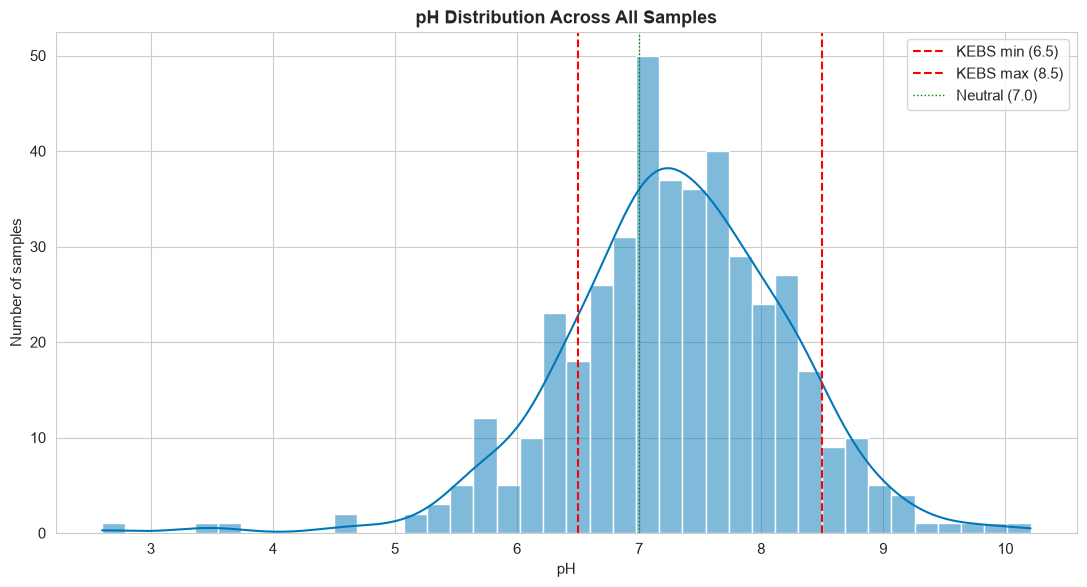

In [25]:
fig, ax = plt.subplots()
sns.histplot(kewi[PH].dropna(), bins=40, kde=True, color="#0077b6", ax=ax)
ax.axvline(KEBS["ph_min"], color="red", linestyle="--", linewidth=1.5, label="KEBS min (6.5)")
ax.axvline(KEBS["ph_max"], color="red", linestyle="--", linewidth=1.5, label="KEBS max (8.5)")
ax.axvline(7.0, color="green", linestyle=":", linewidth=1, label="Neutral (7.0)")
ax.set_title("pH Distribution Across All Samples")
ax.set_xlabel("pH"); ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/01_ph_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 2: pH by Source Type

C:\Users\user\AppData\Local\Temp\ipykernel_13884\3034788577.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=src_data, x=COL_SOURCE, y=PH, order=order, palette="viridis", ax=ax)


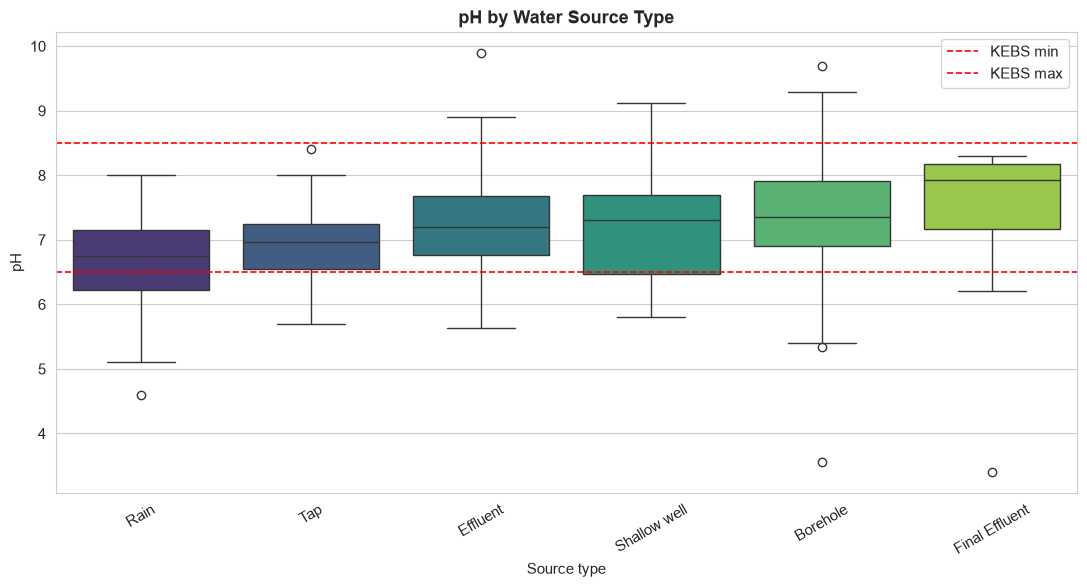

In [27]:
src_data = kewi[[COL_SOURCE, PH]].dropna()
top_src = src_data[COL_SOURCE].value_counts().head(6).index
src_data = src_data[src_data[COL_SOURCE].isin(top_src)]
order = src_data.groupby(COL_SOURCE)[PH].median().sort_values().index

fig, ax = plt.subplots()
sns.boxplot(data=src_data, x=COL_SOURCE, y=PH, order=order, palette="viridis", ax=ax)
ax.axhline(KEBS["ph_min"], color="red", linestyle="--", linewidth=1.2, label="KEBS min")
ax.axhline(KEBS["ph_max"], color="red", linestyle="--", linewidth=1.2, label="KEBS max")
ax.set_title("pH by Water Source Type")
ax.set_xlabel("Source type"); ax.set_ylabel("pH")
ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout()
plt.savefig("output/charts/02_ph_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 3: pH by County (n ≥ 5)

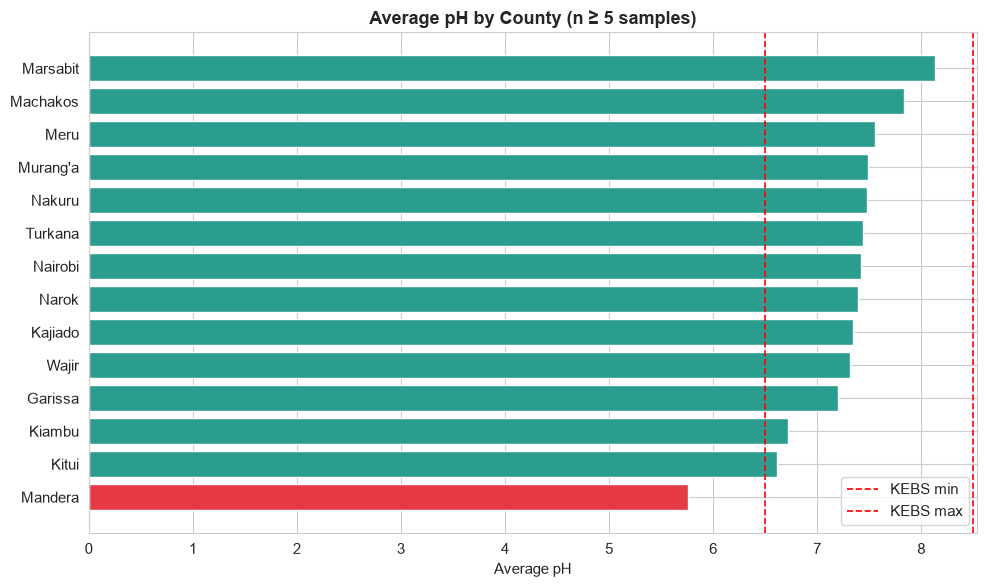

In [28]:
by_county = kewi_ke.groupby("county_clean")[PH].agg(["mean", "count"]).reset_index()
by_county.columns = ["county", "avg_ph", "n"]
by_county = by_county[by_county["n"] >= 5].sort_values("avg_ph")
by_county.to_csv("output/results/ph_by_county.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(by_county)*0.4)))
colors = ["#e63946" if (v < KEBS["ph_min"] or v > KEBS["ph_max"]) else "#2a9d8f"
          for v in by_county["avg_ph"]]
ax.barh(by_county["county"], by_county["avg_ph"], color=colors)
ax.axvline(KEBS["ph_min"], color="red", linestyle="--", linewidth=1.2, label="KEBS min")
ax.axvline(KEBS["ph_max"], color="red", linestyle="--", linewidth=1.2, label="KEBS max")
ax.set_title("Average pH by County (n ≥ 5 samples)")
ax.set_xlabel("Average pH"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("output/charts/03_ph_by_county.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 4: Conductivity Distribution

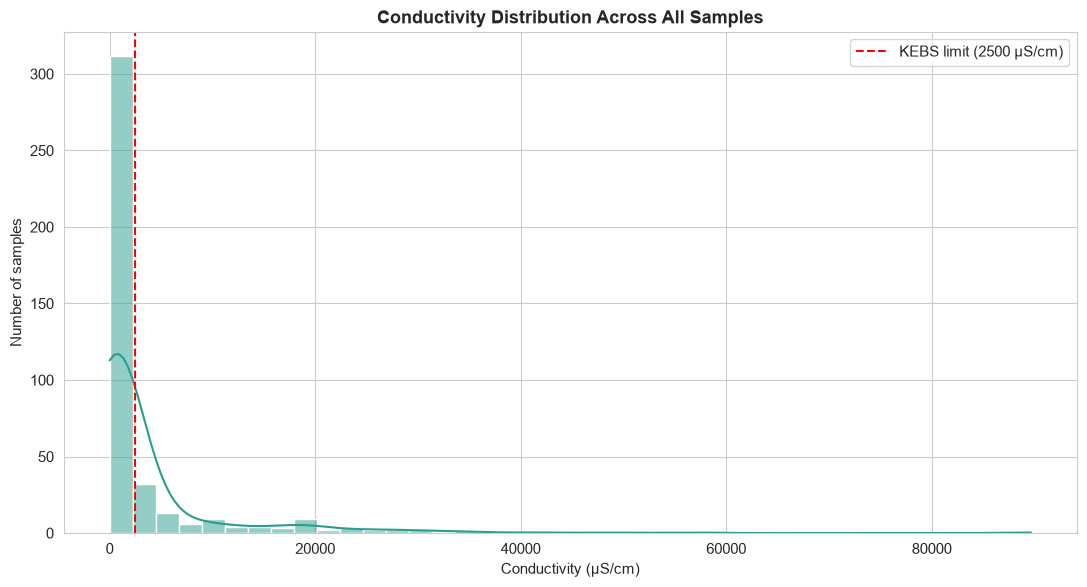

In [29]:
fig, ax = plt.subplots()
sns.histplot(kewi[COND].dropna(), bins=40, kde=True, color="#2a9d8f", ax=ax)
ax.axvline(KEBS["conductivity"], color="red", linestyle="--", linewidth=1.5,
           label=f"KEBS limit ({KEBS['conductivity']} µS/cm)")
ax.set_title("Conductivity Distribution Across All Samples")
ax.set_xlabel("Conductivity (µS/cm)"); ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/04_conductivity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
 Chart 5:  Conductivity by Source

C:\Users\user\AppData\Local\Temp\ipykernel_13884\2238755383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cond.index, y=avg_cond.values, palette="crest", ax=ax)


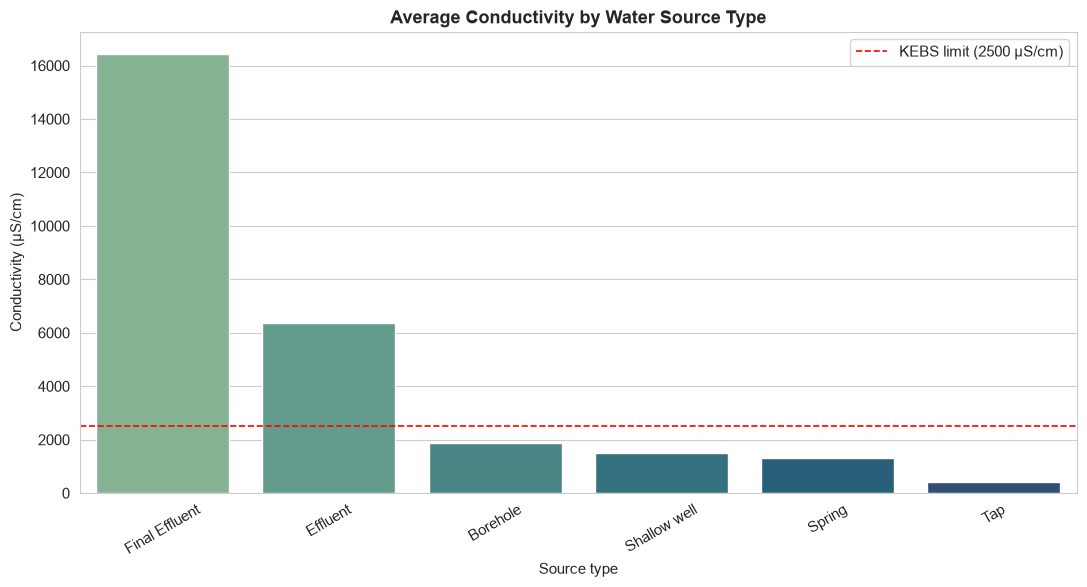

In [30]:
src_cond = kewi[[COL_SOURCE, COND]].dropna()
top_src = src_cond[COL_SOURCE].value_counts().head(6).index
src_cond = src_cond[src_cond[COL_SOURCE].isin(top_src)]
avg_cond = src_cond.groupby(COL_SOURCE)[COND].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=avg_cond.index, y=avg_cond.values, palette="crest", ax=ax)
ax.axhline(KEBS["conductivity"], color="red", linestyle="--", linewidth=1.2,
           label=f"KEBS limit ({KEBS['conductivity']} µS/cm)")
ax.set_title("Average Conductivity by Water Source Type")
ax.set_xlabel("Source type"); ax.set_ylabel("Conductivity (µS/cm)")
ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout()
plt.savefig("output/charts/05_conductivity_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

 Chart 6: Conductivity by County (n ≥ 5)

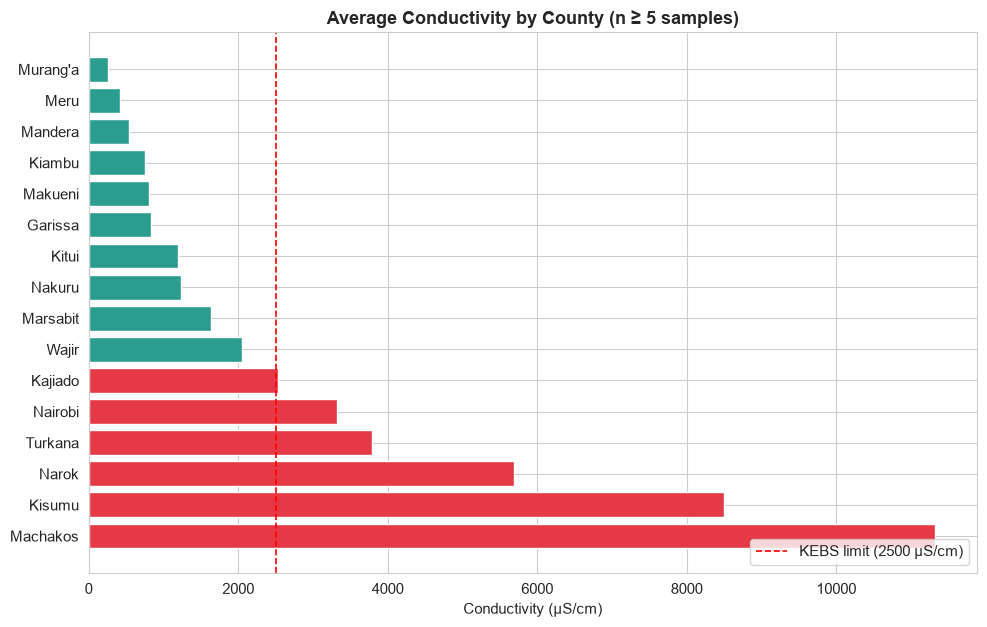

In [31]:
cond_county = kewi_ke.groupby("county_clean")[COND].agg(["mean", "count"]).reset_index()
cond_county.columns = ["county", "avg_cond", "n"]
cond_county = cond_county[cond_county["n"] >= 5].sort_values("avg_cond", ascending=False)
cond_county.to_csv("output/results/conductivity_by_county.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(cond_county)*0.4)))
colors = ["#e63946" if v > KEBS["conductivity"] else "#2a9d8f" for v in cond_county["avg_cond"]]
ax.barh(cond_county["county"], cond_county["avg_cond"], color=colors)
ax.axvline(KEBS["conductivity"], color="red", linestyle="--", linewidth=1.2,
           label=f"KEBS limit ({KEBS['conductivity']} µS/cm)")
ax.set_title("Average Conductivity by County (n ≥ 5 samples)")
ax.set_xlabel("Conductivity (µS/cm)"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("output/charts/06_conductivity_by_county.png", dpi=150, bbox_inches="tight")
plt.show()

 Chart 7:  TDS Distribution

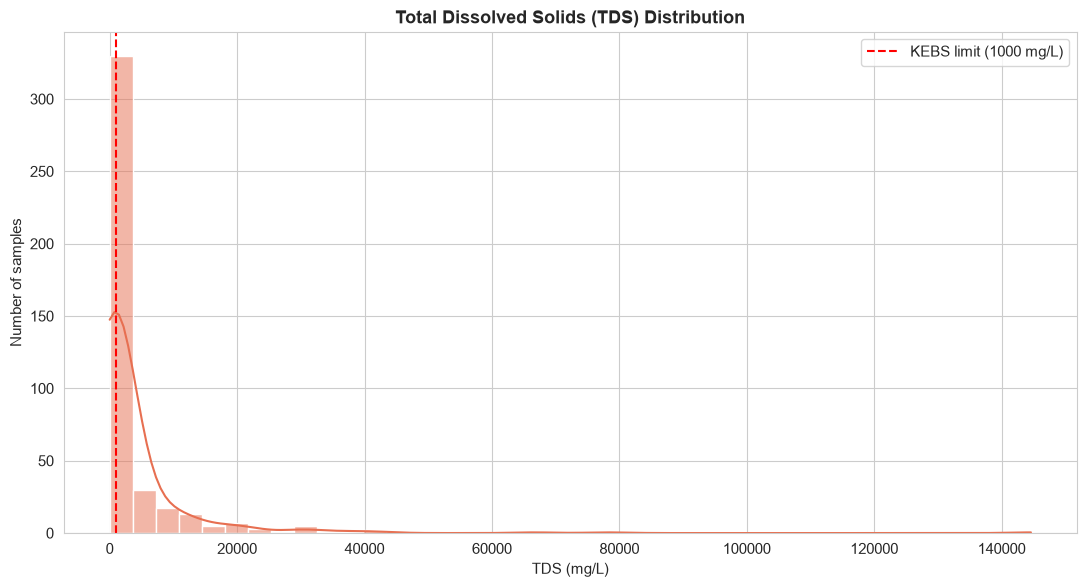

In [32]:
fig, ax = plt.subplots()
sns.histplot(kewi[TDS].dropna(), bins=40, kde=True, color="#e76f51", ax=ax)
ax.axvline(KEBS["tds"], color="red", linestyle="--", linewidth=1.5,
           label=f"KEBS limit ({KEBS['tds']} mg/L)")
ax.set_title("Total Dissolved Solids (TDS) Distribution")
ax.set_xlabel("TDS (mg/L)"); ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/07_tds_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

 Chart 8: Correlation Heatmap

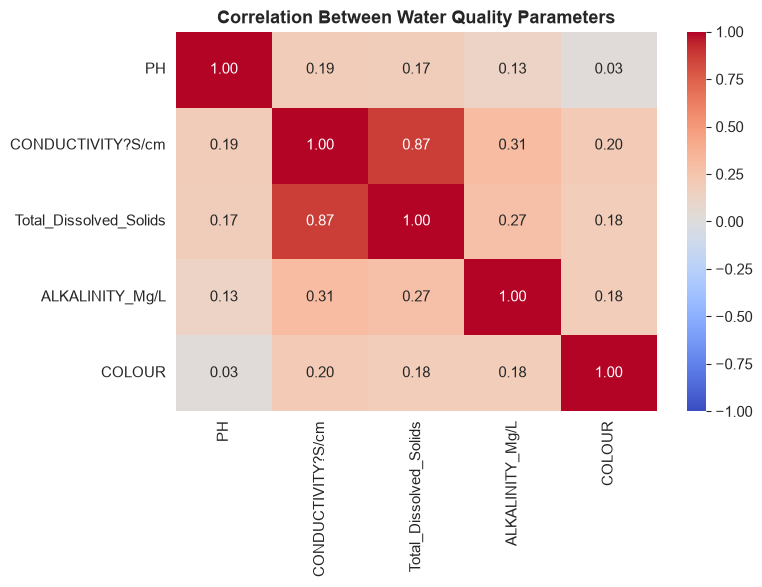

In [33]:
corr_cols = [c for c in [PH, COND, TDS, ALK, COL] if c]
corr_data = kewi[corr_cols].dropna(how="all")
corr_matrix = corr_data.corr()
corr_matrix.to_csv("output/results/correlation_matrix.csv")

labels = [c.replace("_num", "") for c in corr_cols]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            xticklabels=labels, yticklabels=labels, fmt=".2f",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Between Water Quality Parameters")
plt.tight_layout()
plt.savefig("output/charts/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

 Final Findings Summary

In [34]:
findings = []

if PH:
    v = kewi[PH].dropna()
    out = ((v < KEBS["ph_min"]) | (v > KEBS["ph_max"])).sum()
    findings.append(f"pH: {out} of {len(v)} samples ({out/len(v)*100:.1f}%) outside KEBS range 6.5–8.5.")

if COND:
    v = kewi[COND].dropna()
    over = (v > KEBS["conductivity"]).sum()
    findings.append(f"Conductivity: {over} of {len(v)} samples exceed 2500 µS/cm.")

if TDS:
    v = kewi[TDS].dropna()
    over = (v > KEBS["tds"]).sum()
    findings.append(f"TDS: {over} of {len(v)} samples exceed 1000 mg/L.")

findings.append(f"Counties with ≥ 5 samples: {kewi_ke['county_clean'].value_counts()[kewi_ke['county_clean'].value_counts() >= 5].shape[0]}")

with open("output/results/FINDINGS.txt", "w", encoding="utf-8") as f:
    for finding in findings:
        f.write(f"- {finding}\n\n")

print("=" * 60)
print("FINAL FINDINGS")
print("=" * 60)
for finding in findings:
    print(f"• {finding}")

print(f"\n✅ Charts: {len(os.listdir('output/charts'))}")

FINAL FINDINGS
• pH: 96 of 433 samples (22.2%) outside KEBS range 6.5–8.5.
• Conductivity: 90 of 410 samples exceed 2500 µS/cm.
• TDS: 170 of 417 samples exceed 1000 mg/L.
• Counties with ≥ 5 samples: 16

✅ Charts: 28
